In [ ]:
from fractions import Fraction
import re
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

class SimplexDictionarySolver:
    def __init__(self, num_vars, num_constraints, objective_type, c, A, b, bound_signs, var_signs, pivot_rule="BLAND"):
        """
        Khởi tạo và lưu trữ các tham số đầu vào gốc.
        Sử dụng Fraction để triệt tiêu hoàn toàn sai số dấu phẩy động.
        """
        self.original_num_vars = num_vars
        self.original_num_constraints = num_constraints
        self.objective_type = objective_type.upper() # 'MAX' hoặc 'MIN'

        self.pivot_rule = pivot_rule.upper() # 'BLAND' hoặc 'DANTZIG'
        self.max_iterations = 1000 # Ngưỡng tối đa để chống lặp vô tận
        self.iteration_count = 0 # Bộ đếm số bước xoay

        # Chuyển đổi toàn bộ dữ liệu số sang dạng phân số (Fraction) để tránh sai số
        self.c = [Fraction(str(val)) for val in c]
        self.b = [Fraction(str(val)) for val in b]
        self.A = [[Fraction(str(val)) for val in row] for row in A]

        self.bound_signs = [sign.strip() for sign in bound_signs]
        self.var_signs = [sign.replace(" ", "") for sign in var_signs]

        # Lưu lại ma trận gốc để vẽ hình
        self.orig_A = copy.deepcopy(self.A)
        self.orig_b = copy.deepcopy(self.b)
        self.orig_bound_signs = copy.deepcopy(self.bound_signs)

        # Trạng thái hệ thống (Từ vựng)
        self.B = [] # Tập biến cơ sở
        self.N = [] # Tập biến phi cơ sở
        self.dictionary = {} # Lưu trữ hệ phương trình từ vựng: {var_B: {'const': val, var_N1: val, ...}}
        self.objective_func = {} # Lưu hàm mục tiêu hiện tại (Z hoặc W)
        self.Z = {'const': Fraction(0)} # Hàm mục tiêu chính (Từ Mã nguồn 1)
        self.W = {'const': Fraction(0)} # Hàm mục tiêu Pha 1 (Từ Mã nguồn 1)

        self.status = "INITIALIZED" # Trạng thái bài toán
        self.has_infinite_solutions = False
        self.history = [] # Lưu lại lịch sử từng bước để vẽ UI (hiển thị lên Streamlit)

        # Biến phụ trợ để lưu vết phục hồi nghiệm nguyên thủy (x <= 0, tùy ý)
        self.original_var_mapping = {} # Lưu vết biến đổi biến
        self.var_mapping = {} # Ví dụ: 'x1': [('x1_plus', 1), ('x1_minus', -1)]
        self.original_Z_expr = {} # Biểu thức Z sau khi chuẩn hóa biến

    # ==========================================
    # BƯỚC 0: CHUẨN HÓA BÀI TOÁN
    # ==========================================
    def standardize_problem(self):
        """
        Đưa bài toán về dạng chuẩn (MIN & <=) theo đúng mã giả.
        1. Chuẩn hóa biến (x <= 0, x tùy ý).
        2. Chuẩn hóa hàm MAX thành MIN.
        3. Tách dấu '=' thành <= và >=, đảo dấu >= thành <=.
        """
        new_c = []
        new_A = [[] for _ in range(self.original_num_constraints)]
        var_idx = 1

        # 1. Chuẩn hóa biến (x <= 0, x tùy ý)
        for j in range(self.original_num_vars):
            orig_var = f"x{j+1}"
            sign = self.var_signs[j]

            if sign == ">=0":
                new_var = f"x{var_idx}"
                self.original_var_mapping[orig_var] = [new_var]
                self.var_mapping[orig_var] = [(new_var, 1)] # 1 là hệ số dương
                new_c.append(self.c[j])
                for i in range(self.original_num_constraints): new_A[i].append(self.A[i][j])
                self.N.append(new_var)
                var_idx += 1

            elif sign == "<=0":
                new_var = f"x{var_idx}"
                self.original_var_mapping[orig_var] = [f"-{new_var}"]
                self.var_mapping[orig_var] = [(new_var, -1)]
                new_c.append(-self.c[j])
                for i in range(self.original_num_constraints): new_A[i].append(-self.A[i][j])
                self.N.append(new_var)
                var_idx += 1

            elif sign == "free" or sign == "tùyý":
                var_plus = f"x{var_idx}"
                var_minus = f"x{var_idx+1}"
                self.original_var_mapping[orig_var] = [var_plus, f"-{var_minus}"]
                self.var_mapping[orig_var] = [(var_plus, 1), (var_minus, -1)]
                new_c.extend([self.c[j], -self.c[j]])
                for i in range(self.original_num_constraints):
                    new_A[i].extend([self.A[i][j], -self.A[i][j]])
                self.N.extend([var_plus, var_minus])
                var_idx += 2

        # 2. Chuẩn hóa hàm mục tiêu (MAX -> MIN)
        is_max = (self.objective_type == 'MAX')
        multiplier = Fraction(-1) if is_max else Fraction(1)
        self.original_Z_expr = {'const': Fraction(0)}

        for j, var in enumerate(self.N):
            # Nếu gốc là MAX, ta nhân -1 để đưa về MIN
            coeff = new_c[j] * multiplier
            self.original_Z_expr[var] = coeff
            self.Z[var] = coeff # Đồng bộ trạng thái Z ban đầu

        # 3. Chuẩn hóa ràng buộc (Đưa về <=)
        final_A, final_b = [], []
        for i in range(self.original_num_constraints):
            if self.bound_signs[i] == '<=':
                final_A.append(new_A[i])
                final_b.append(self.b[i])
            elif self.bound_signs[i] == '>=':
                final_A.append([-val for val in new_A[i]])
                final_b.append(-self.b[i])
            elif self.bound_signs[i] == '=':
                # Tách thành <= và >= (rồi đảo dấu >= lập tức nhân -1 thành <=)
                final_A.append(new_A[i])
                final_b.append(self.b[i])
                final_A.append([-val for val in new_A[i]])
                final_b.append(-self.b[i])

        self.A = final_A
        self.b = final_b

    # ==========================================
    # BƯỚC 1: LẬP TỪ VỰNG VÀ RẼ NHÁNH
    # ==========================================
    def build_initial_dictionary(self):
        """
        Thêm biến bù (slack variables - w_i).
        Kiểm tra vector b để quyết định đi thẳng Pha 2 hay phải qua Pha 1.
        """
        for i in range(len(self.b)):
            w_var = f"w{i+1}"
            self.B.append(w_var)
            self.dictionary[w_var] = {'const': self.b[i]}
            for j, x_var in enumerate(self.N):
                # w_i = b_i - sum(a_ij * x_j) => Hệ số lưu trữ là -a_ij
                self.dictionary[w_var][x_var] = -self.A[i][j]

        # Rẽ nhánh: Có b_i < 0 không? Nếu có bất kỳ b_i < 0, bắt buộc qua Pha 1
        return any(val < 0 for val in self.b)

    # ==========================================
    # BƯỚC 2: PHA 1 (TÌM MIỀN KHẢ THI)
    # ==========================================
    def phase_1(self):
        """
        Thêm biến giả x0.
        Khởi tạo hàm mục tiêu W = x0.
        Special Pivot để đẩy x0 vào cơ sở.
        Gọi simplex_loop(W).
        Xử lý x0 sau khi kết thúc Pha 1.
        """
        # 1. Khởi tạo x0 và thêm vào tất cả các phương trình
        self.N.append('x0')
        for w_var in self.B:
            self.dictionary[w_var]['x0'] = Fraction(1)

        # Khởi tạo hàm mục tiêu Pha 1: MIN W = x0
        self.objective_func = {'const': Fraction(0), 'x0': Fraction(1)}
        self.W = self.objective_func # Đồng bộ biến W
        for x_var in self.N:
            if x_var != 'x0': self.objective_func[x_var] = Fraction(0)

        # 2. Special Initial Pivot: Ép x0 vào cơ sở, biến ra là w_k có b_k âm nhất
        leaving_var = min(self.B, key=lambda v: (self.dictionary[v]['const'], self._sort_key(v)))
        self.pivot('x0', leaving_var, self.objective_func)

        # 3. Chạy Simplex Pha 1
        status = self.simplex_loop(self.objective_func)
        if status == "UNBOUNDED":
            return False # Lý thuyết Pha 1 không thể Unbounded, nhưng đặt để an toàn

        # 4. Đánh giá Pha 1
        W_opt = self.objective_func.get('const', Fraction(0))
        if W_opt > 0:
            return False # Hệ vô nghiệm

        if W_opt == 0:
            # Nếu x0 vẫn kẹt trong cơ sở B
            if 'x0' in self.B:
                eq = self.dictionary['x0']
                # Tìm biến phi cơ sở có hệ số khác 0 để pivot x0 ra
                valid_entering = [v for v in self.N if v != 'x0' and eq.get(v, Fraction(0)) != 0]
                if not valid_entering:
                    # Ràng buộc dư thừa, xóa bỏ
                    self.B.remove('x0')
                    del self.dictionary['x0']
                else:
                    # Ưu tiên Bland rule để chọn biến vào
                    entering_var = min(valid_entering, key=self._sort_key)
                    self.pivot(entering_var, 'x0', self.objective_func)

            # Dọn dẹp hoàn toàn x0 khỏi hệ thống
            if 'x0' in self.N: self.N.remove('x0')
            for b_var in self.B:
                if 'x0' in self.dictionary[b_var]:
                    del self.dictionary[b_var]['x0']
            return True

    # ==========================================
    # BƯỚC 3: PHA 2 (TÌM NGHIỆM TỐI ƯU)
    # ==========================================
    def phase_2(self):
        """
        Khôi phục hàm Z gốc.
        Thế các biến cơ sở B vào Z.
        Gọi simplex_loop(Z).
        """
        # 1. Khôi phục hàm Z gốc
        self.objective_func = {'const': self.original_Z_expr['const']}
        for v in self.N: self.objective_func[v] = Fraction(0)

        # 2. Thế biểu thức của các biến (nếu chúng đang ở trong B) vào Z
        for var, coeff in self.original_Z_expr.items():
            if var == 'const' or coeff == 0: continue

            if var in self.N:
                self.objective_func[var] = self.objective_func.get(var, Fraction(0)) + coeff
            elif var in self.B:
                eq = self.dictionary[var]
                self.objective_func['const'] += coeff * eq['const']
                for n_var in self.N:
                    self.objective_func[n_var] = self.objective_func.get(n_var, Fraction(0)) + coeff * eq.get(n_var, Fraction(0))

        self.Z = self.objective_func # Cập nhật Z thực tế sau khi thế

        # 3. Chạy Simplex Pha 2
        self.status = self.simplex_loop(self.objective_func)

    # ==========================================
    # BƯỚC 4: HÀM CỐT LÕI - SIMPLEX LOOP
    # ==========================================
    def simplex_loop(self, objective_func):
        """
        Vòng lặp Simplex chung cho cả Pha 1 và Pha 2.
        - Chọn biến vào (Tùy chọn Quy tắc Bland hoặc Dantzig).
        - Chọn biến ra (Quy tắc tỷ số, hòa thì dùng Bland).
        - Cập nhật Dictionary (Pivot).
        - Tích hợp cơ chế Anti-Cycling (Tự động lùi về Bland nếu đạp vòng).
        Lưu ý: Dùng yield hoặc lưu vào self.history để theo dõi trạng thái.
        """
        while True:
            # --- CƠ CHẾ BỔ SUNG: Chống đạp vòng (Anti-Cycling Fallback) ---
            self.iteration_count += 1
            if self.iteration_count > self.max_iterations:
                if self.pivot_rule == "DANTZIG":
                    # Đang dùng Dantzig mà bị lặp vô hạn -> Ép về Bland để thoát
                    self.pivot_rule = "BLAND"
                    self.iteration_count = 0
                else:
                    # Nếu dùng Bland mà vẫn quá giới hạn (có thể do lỗi dữ liệu)
                    return "MAX_ITERATIONS_REACHED"

            self._save_history(objective_func)

            # 1. Kiểm tra dừng & Chọn Biến Vào (Entering)
            # Vì ta luôn dùng hàm MIN, ta tìm các biến phi cơ sở có hệ số < 0
            entering_candidates = [v for v in self.N if objective_func.get(v, Fraction(0)) < 0]

            if not entering_candidates:
                return "OPTIMAL" # Đã tối ưu (Mọi c_j >= 0)

            # --- CƠ CHẾ BỔ SUNG: Lựa chọn Quy tắc ---
            if getattr(self, 'pivot_rule', 'BLAND') == "DANTZIG":
                # Quy tắc DANTZIG: Chọn biến có hệ số âm nhất
                min_coeff = min(objective_func[v] for v in entering_candidates)
                best_entering = [v for v in entering_candidates if objective_func[v] == min_coeff]
                # Nếu hòa hệ số âm, dùng Bland để bẻ khóa
                entering_var = min(best_entering, key=self._sort_key)
            else:
                # Quy tắc BLAND (Mặc định): Chọn biến có chỉ số nhỏ nhất
                entering_var = min(entering_candidates, key=self._sort_key)

            # 2. Chọn Biến Ra (Leaving) - Quy tắc tỷ số
            leaving_candidates = []
            for b_var in self.B:
                coeff = self.dictionary[b_var].get(entering_var, Fraction(0))
                # Trong phương trình: x_B = b - |coeff| * x_in. Ta cần coeff < 0
                # coef âm nghĩa là khi chuyển vế nó mang dấu dương (b_i - c_ij*x_j)
                if coeff < 0:
                    ratio = self.dictionary[b_var]['const'] / abs(coeff)
                    leaving_candidates.append((ratio, b_var))

            if not leaving_candidates:
                return "UNBOUNDED" # Không bị chặn

            # Tìm ratio nhỏ nhất, nếu hòa thì chọn theo Bland
            min_ratio = min(leaving_candidates, key=lambda x: x[0])[0]
            best_candidates = [var for ratio, var in leaving_candidates if ratio == min_ratio]
            leaving_var = min(best_candidates, key=self._sort_key)

            # 3. Thực hiện Pivot (Cập nhật Dictionary)
            self.pivot(entering_var, leaving_var, objective_func)

    def pivot(self, entering_var, leaving_var, objective):
        """
        Thực hiện phép thế toán học: biểu diễn entering_var theo leaving_var
        và cập nhật toàn bộ hệ phương trình, hàm mục tiêu.
        """
        self.B.remove(leaving_var)
        self.N.remove(entering_var)
        self.B.append(entering_var)
        self.N.append(leaving_var)

        # Rút biến vào từ phương trình của biến ra (Rút entering theo leaving)
        eq = self.dictionary[leaving_var]
        new_eq = {}
        coeff_enter = eq[entering_var] # Chắc chắn < 0 theo logic chọn biến ra

        new_eq['const'] = eq['const'] / (-coeff_enter)
        for var in eq:
            if var not in ['const', entering_var]:
                new_eq[var] = eq[var] / (-coeff_enter)
        new_eq[leaving_var] = Fraction(1) / coeff_enter

        # Cập nhật Từ vựng cho biến vào
        del self.dictionary[leaving_var]
        self.dictionary[entering_var] = new_eq

        # Thế biến vào (vừa rút) vào các phương trình khác
        for b_var in self.B:
            if b_var == entering_var: continue
            b_eq = self.dictionary[b_var]
            if entering_var in b_eq:
                factor = b_eq[entering_var]
                b_eq['const'] += factor * new_eq['const']
                for n_var in self.N:
                    b_eq[n_var] = b_eq.get(n_var, Fraction(0)) + factor * new_eq.get(n_var, Fraction(0))
                del b_eq[entering_var]

        # Thế biến vào vào hàm mục tiêu
        factor = objective.get(entering_var, Fraction(0))
        if factor != 0:
            objective['const'] += factor * new_eq['const']
            for n_var in self.N:
                objective[n_var] = objective.get(n_var, Fraction(0)) + factor * new_eq.get(n_var, Fraction(0))
            del objective[entering_var]

    # ==========================================
    # BƯỚC 5: TRÍCH XUẤT KẾT QUẢ
    # ==========================================
    def extract_solution(self):
        """
        Nhận diện Vô số nghiệm (has_infinite_solutions).
        Tính giá trị biến nguyên thủy.
        Đảo dấu Z_opt nếu bài toán gốc là MAX.
        """
        if self.status != "OPTIMAL": return

        # 1. Nhận diện vô số nghiệm
        for n_var in self.N:
            if self.objective_func.get(n_var, Fraction(0)) == 0:
                has_negative_coeff = False
                for b_var in self.B:
                    if self.dictionary[b_var].get(n_var, Fraction(0)) < 0:
                        has_negative_coeff = True
                        break

                if not has_negative_coeff:
                    self.has_infinite_solutions = True
                else:
                    for b_var in self.B:
                        coeff = self.dictionary[b_var].get(n_var, Fraction(0))
                        if coeff < 0:
                            ratio = self.dictionary[b_var]['const'] / abs(coeff)
                            if ratio > 0:
                                self.has_infinite_solutions = True

        # 2. Tính giá trị biến nguyên thủy
        self.final_vars = {}
        for j in range(self.original_num_vars):
            orig_var = f"x{j+1}"
            total_val = Fraction(0)

            for mapped_var, sign_multiplier in self.var_mapping[orig_var]:
                val = Fraction(0)
                if mapped_var in self.B:
                    val = self.dictionary[mapped_var]['const']
                total_val += val * sign_multiplier

            self.final_vars[orig_var] = total_val

        # 3. Đảo dấu Z_opt nếu gốc là MAX
        self.Z_opt = self.objective_func['const']
        if self.objective_type == 'MAX':
            self.Z_opt = -self.Z_opt

    # ==========================================
    # BƯỚC 6: VẼ ĐỒ THỊ MIỀN KHẢ THI (CHỈ HỖ TRỢ 2 BIẾN)
    # ==========================================
    def plot_feasible_region(self):
        """
        Vẽ miền chấp nhận được lên trục tọa độ 2D.
        Hỗ trợ các điều kiện x >= 0, x <= 0, và x tùy ý.
        """
        if self.original_num_vars != 2:
            return None, "Lỗi: Chỉ hỗ trợ vẽ đồ thị cho bài toán có đúng 2 biến quyết định."

        # 1. Dùng ma trận gốc và xử lí dấu ràng buộc
        A_base = []
        b_base = []
        for i in range(self.original_num_constraints):
            row = [float(val) for val in self.orig_A[i]]
            b_val = float(self.orig_b[i])
            sign = self.orig_bound_signs[i]

            if sign == '<=':
                A_base.append(row)
                b_base.append(b_val)
            elif sign == '>=':
                # Đổi chiều để gom về <=
                A_base.append([-val for val in row])
                b_base.append(-b_val)
            elif sign == '=':
                # Dấu = tách thành <= và >= (>= lại đảo dấu thành <=)
                A_base.append(row)
                b_base.append(b_val)
                A_base.append([-val for val in row])
                b_base.append(-b_val)

        extra_A, extra_b = [], []

        # 2. Xử lý dấu cho biến x1
        if self.var_signs[0] == ">=0":
            extra_A.append([-1.0, 0.0]) # -x1 <= 0  (tương đương x1 >= 0)
            extra_b.append(0.0)
        elif self.var_signs[0] == "<=0":
            extra_A.append([1.0, 0.0])  # x1 <= 0
            extra_b.append(0.0)

        # 3. Xử lý dấu cho biến x2
        if self.var_signs[1] == ">=0":
            extra_A.append([0.0, -1.0]) # -x2 <= 0  (tương đương x2 >= 0)
            extra_b.append(0.0)
        elif self.var_signs[1] == "<=0":
            extra_A.append([0.0, 1.0])  # x2 <= 0
            extra_b.append(0.0)

        # 4. Thêm "hàng rào" ẢO cực lớn (M=10000) để đóng kín miền khả thi
        # trong trường hợp biến "tùy ý" hoặc miền không bị chặn, giúp code không bị lỗi khi tìm đa giác lồi
        M = 10000.0
        extra_A.extend([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
        extra_b.extend([M, M, M, M])

        # Gộp tất cả ràng buộc lại
        A_full = np.vstack([A_base, extra_A]) if len(extra_A) > 0 else np.array(A_base)
        b_full = np.append(b_base, extra_b) if len(extra_b) > 0 else np.array(b_base)

        # 5. Tìm TẤT CẢ các giao điểm (Vertices) của các cặp đường thẳng
        num_lines = len(b_full)
        points = []
        for i in range(num_lines):
            for j in range(i + 1, num_lines):
                A_sys = np.array([A_full[i], A_full[j]])
                b_sys = np.array([b_full[i], b_full[j]])
                try:
                    # Giải hệ phương trình tuyến tính
                    pt = np.linalg.solve(A_sys, b_sys)
                    points.append(pt)
                except np.linalg.LinAlgError:
                    continue # Bỏ qua nếu 2 đường thẳng song song/trùng nhau

        # 6. Lọc các điểm thỏa mãn TẤT CẢ các ràng buộc (Miền khả thi)
        valid_points = []
        for pt in points:
            # Kiểm tra A*pt <= b (Cộng thêm 1e-7 để dung sai sai số do Numpy)
            if np.all(np.dot(A_full, pt) <= b_full + 1e-7):
                valid_points.append(pt)

        if not valid_points:
            return None, "Miền khả thi rỗng (Infeasible Region)."

        # Loại bỏ các điểm trùng lặp
        valid_points = np.unique(np.round(valid_points, decimals=5), axis=0)

        # 7. Sắp xếp các điểm theo chiều kim đồng hồ để vẽ đa giác (Convex Polygon)
        center = np.mean(valid_points, axis=0)
        angles = np.arctan2(valid_points[:, 1] - center[1], valid_points[:, 0] - center[0])
        sorted_indices = np.argsort(angles)
        polygon = valid_points[sorted_indices]

        # 8. Khởi tạo hình vẽ Matplotlib
        fig, ax = plt.subplots(figsize=(8, 6))

        # Vẽ đa giác miền khả thi
        poly_patch = Polygon(polygon, closed=True, fill=True, color='lightblue', alpha=0.6, edgecolor='blue')
        ax.add_patch(poly_patch)

        # Vẽ các điểm đỉnh (Vertices)
        ax.plot(polygon[:, 0], polygon[:, 1], 'bo', label='Các đỉnh khả thi')

        # Vẽ điểm tối ưu (nếu đã giải xong)
        if self.status == "OPTIMAL" and hasattr(self, 'final_vars'):
            opt_x1 = float(self.final_vars['x1'])
            opt_x2 = float(self.final_vars['x2'])
            ax.plot(opt_x1, opt_x2, 'ro', markersize=10, label=f'Tối ưu ({opt_x1:.2f}, {opt_x2:.2f})')

        # 9. Thiết lập trục tự động co giãn
        # Loại bỏ những điểm quá lớn (ảo) ra khỏi tính toán giới hạn trục để tránh zoom out quá xa
        plot_points = np.array([pt for pt in polygon if abs(pt[0]) < M/2 and abs(pt[1]) < M/2])

        if len(plot_points) > 0:
            min_x, max_x = np.min(plot_points[:, 0]), np.max(plot_points[:, 0])
            min_y, max_y = np.min(plot_points[:, 1]), np.max(plot_points[:, 1])
        else:
            min_x, max_x, min_y, max_y = -10, 10, -10, 10 # Default fallback

        padding_x = max(abs(max_x - min_x) * 0.2, 2)
        padding_y = max(abs(max_y - min_y) * 0.2, 2)

        ax.set_xlim(min_x - padding_x, max_x + padding_x)
        ax.set_ylim(min_y - padding_y, max_y + padding_y)

        # Kẻ trục tọa độ x=0, y=0 để dễ nhìn các giá trị âm
        ax.axhline(0, color='black', linewidth=1.5)
        ax.axvline(0, color='black', linewidth=1.5)

        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_title('Đồ thị Miền khả thi 2D', fontsize=14)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

        return fig, "Success"

    # ==========================================
    # HÀM ĐIỀU PHỐI & PHỤ TRỢ
    # ==========================================
    def solve(self):
        """Hàm điều phối chính"""
        self.standardize_problem()
        needs_phase_1 = self.build_initial_dictionary()

        if needs_phase_1:
            feasible = self.phase_1()
            if not feasible:
                self.status = "INFEASIBLE"
                return

        self.phase_2()
        self.extract_solution()

    def _sort_key(self, var_name):
        """Hỗ trợ Quy tắc Bland: Ưu tiên x1 < x2 < w1 < w2"""
        # Hàm giúp sắp xếp index của x1, x2, w1, w2... cho quy tắc Bland
        match = re.match(r"([a-zA-Z]+)(\d+)", var_name)
        if match:
            # Nhóm 'x' luôn ưu tiên xếp trước 'w', sau đó so sánh số
            prefix = 0 if match.group(1) == 'x' else 1
            return (prefix, int(match.group(2)))
        return (2, 0)

    def _save_history(self, obj_func):
        """Lưu lại trạng thái để vẽ giao diện từng bước (record history)"""
        state = {
            'B': list(self.B),
            'N': list(self.N),
            'dict': copy.deepcopy(self.dictionary),
            'obj': copy.deepcopy(obj_func)
        }
        self.history.append(state)

In [ ]:
def print_test_results(test_name, solver, expected_str):
    print(f"\n{'='*20} {test_name} {'='*20}")
    print(f"Kỳ vọng: {expected_str}")
    print(f"Trạng thái thực tế: {solver.status}")

    if solver.history:
        print("\n--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---")
        for i, step in enumerate(solver.history):
            print(f"Bước {i}: B={step['B']}, N={step['N']}")
            print(f"  Hàm mục tiêu: {step['obj']}")
            # In một vài dòng dictionary đại diện
            for b_var, expr in step['dict'].items():
                print(f"  {b_var} = {expr}")
            print("-"*30)

    if solver.status == "OPTIMAL":
        print(f"\nKẾT QUẢ CUỐI CÙNG:")
        print(f"  Z_opt: {solver.Z_opt}")
        print(f"  Biến: {solver.final_vars}")
        if solver.has_infinite_solutions:
            print("  (!) Phát hiện có VÔ SỐ NGHIỆM")

    print(f"{'='*50}\n")

### TEST 1: Bài toán chuẩn (Pha 2)

In [ ]:
solver1 = SimplexDictionarySolver(
    num_vars=2, num_constraints=2, objective_type='MAX',
    c=[3, 2], A=[[1, 1], [2, 1]], b=[4, 5],
    bound_signs=['<=', '<='], var_signs=['>=0', '>=0']
)
solver1.solve()
print_test_results("TEST 1: Bài toán chuẩn", solver1, "OPTIMAL | Z = 9 | x1 = 1, x2 = 3")


==================== TEST 1: Bài toán chuẩn ====================
Kỳ vọng: OPTIMAL | Z = 9 | x1 = 1, x2 = 3
Trạng thái thực tế: OPTIMAL

--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---
Bước 0: B=['w1', 'w2'], N=['x1', 'x2']
  Hàm mục tiêu: {'const': Fraction(0, 1), 'x1': Fraction(-3, 1), 'x2': Fraction(-2, 1)}
  w1 = {'const': Fraction(4, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(-1, 1)}
  w2 = {'const': Fraction(5, 1), 'x1': Fraction(-2, 1), 'x2': Fraction(-1, 1)}
------------------------------
Bước 1: B=['w1', 'x1'], N=['x2', 'w2']
  Hàm mục tiêu: {'const': Fraction(-15, 2), 'x2': Fraction(-1, 2), 'w2': Fraction(3, 2)}
  w1 = {'const': Fraction(3, 2), 'x2': Fraction(-1, 2), 'w2': Fraction(1, 2)}
  x1 = {'const': Fraction(5, 2), 'x2': Fraction(-1, 2), 'w2': Fraction(-1, 2)}
------------------------------
Bước 2: B=['x1', 'x2'], N=['w2', 'w1']
  Hàm mục tiêu: {'const': Fraction(-9, 1), 'w2': Fraction(1, 1), 'w1': Fraction(1, 1)}
  x1 = {'const': Fraction(1, 1), 'w2': Fraction(-1, 1), 'w1':

### TEST 2: Cần Pha 1 (Tìm miền khả thi)

In [ ]:
solver2 = SimplexDictionarySolver(
    num_vars=2, num_constraints=2, objective_type='MIN',
    c=[-3, 1], A=[[1, 1], [1, 0]], b=[2, 1],
    bound_signs=['=', '>='], var_signs=['>=0', '>=0']
)
solver2.solve()
print_test_results("TEST 2: Cần Pha 1", solver2, "OPTIMAL | Z = -6 | x1 = 2, x2 = 0")


==================== TEST 2: Cần Pha 1 ====================
Kỳ vọng: OPTIMAL | Z = -6 | x1 = 2, x2 = 0
Trạng thái thực tế: OPTIMAL

--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---
Bước 0: B=['w1', 'w3', 'x0'], N=['x1', 'x2', 'w2']
  Hàm mục tiêu: {'const': Fraction(2, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(-1, 1), 'w2': Fraction(1, 1)}
  w1 = {'const': Fraction(4, 1), 'x1': Fraction(-2, 1), 'x2': Fraction(-2, 1), 'w2': Fraction(1, 1)}
  w3 = {'const': Fraction(1, 1), 'x1': Fraction(0, 1), 'x2': Fraction(-1, 1), 'w2': Fraction(1, 1)}
  x0 = {'const': Fraction(2, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(-1, 1), 'w2': Fraction(1, 1)}
------------------------------
Bước 1: B=['w1', 'w3', 'x1'], N=['x2', 'w2', 'x0']
  Hàm mục tiêu: {'const': Fraction(0, 1), 'x2': Fraction(0, 1), 'w2': Fraction(0, 1), 'x0': Fraction(1, 1)}
  w1 = {'const': Fraction(0, 1), 'x2': Fraction(0, 1), 'w2': Fraction(-1, 1), 'x0': Fraction(2, 1)}
  w3 = {'const': Fraction(1, 1), 'x2': Fraction(-1, 1), 'w2': Fraction

### TEST 3: Vô nghiệm (Infeasible)

In [ ]:
solver3 = SimplexDictionarySolver(
    num_vars=2, num_constraints=2, objective_type='MAX',
    c=[1, 1], A=[[1, 1], [1, 1]], b=[2, 4],
    bound_signs=['<=', '>='], var_signs=['>=0', '>=0']
)
solver3.solve()
print_test_results("TEST 3: Vô nghiệm", solver3, "INFEASIBLE")


==================== TEST 3: Vô nghiệm ====================
Kỳ vọng: INFEASIBLE
Trạng thái thực tế: INFEASIBLE

--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---
Bước 0: B=['w1', 'x0'], N=['x1', 'x2', 'w2']
  Hàm mục tiêu: {'const': Fraction(4, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(-1, 1), 'w2': Fraction(1, 1)}
  w1 = {'const': Fraction(6, 1), 'x1': Fraction(-2, 1), 'x2': Fraction(-2, 1), 'w2': Fraction(1, 1)}
  x0 = {'const': Fraction(4, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(-1, 1), 'w2': Fraction(1, 1)}
------------------------------
Bước 1: B=['x0', 'x1'], N=['x2', 'w2', 'w1']
  Hàm mục tiêu: {'const': Fraction(1, 1), 'x2': Fraction(0, 1), 'w2': Fraction(1, 2), 'w1': Fraction(1, 2)}
  x0 = {'const': Fraction(1, 1), 'x2': Fraction(0, 1), 'w2': Fraction(1, 2), 'w1': Fraction(1, 2)}
  x1 = {'const': Fraction(3, 1), 'x2': Fraction(-1, 1), 'w2': Fraction(1, 2), 'w1': Fraction(-1, 2)}
------------------------------



### TEST 4: Không giới nội (Unbounded)

In [ ]:
solver4 = SimplexDictionarySolver(
    num_vars=2, num_constraints=1, objective_type='MAX',
    c=[2, 1], A=[[1, -1]], b=[10],
    bound_signs=['<='], var_signs=['>=0', '>=0']
)
solver4.solve()
print_test_results("TEST 4: Không giới nội", solver4, "UNBOUNDED")


==================== TEST 4: Không giới nội ====================
Kỳ vọng: UNBOUNDED
Trạng thái thực tế: UNBOUNDED

--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---
Bước 0: B=['w1'], N=['x1', 'x2']
  Hàm mục tiêu: {'const': Fraction(0, 1), 'x1': Fraction(-2, 1), 'x2': Fraction(-1, 1)}
  w1 = {'const': Fraction(10, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(1, 1)}
------------------------------
Bước 1: B=['x1'], N=['x2', 'w1']
  Hàm mục tiêu: {'const': Fraction(-20, 1), 'x2': Fraction(-3, 1), 'w1': Fraction(2, 1)}
  x1 = {'const': Fraction(10, 1), 'x2': Fraction(1, 1), 'w1': Fraction(-1, 1)}
------------------------------



### TEST 5: Vô số nghiệm

In [ ]:
solver5 = SimplexDictionarySolver(
    num_vars=2, num_constraints=1, objective_type='MAX',
    c=[2, 4], A=[[1, 2]], b=[5],
    bound_signs=['<='], var_signs=['>=0', '>=0']
)
solver5.solve()
print_test_results("TEST 5: Vô số nghiệm", solver5, "OPTIMAL | has_infinite_solutions = True")


==================== TEST 5: Vô số nghiệm ====================
Kỳ vọng: OPTIMAL | has_infinite_solutions = True
Trạng thái thực tế: OPTIMAL

--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---
Bước 0: B=['w1'], N=['x1', 'x2']
  Hàm mục tiêu: {'const': Fraction(0, 1), 'x1': Fraction(-2, 1), 'x2': Fraction(-4, 1)}
  w1 = {'const': Fraction(5, 1), 'x1': Fraction(-1, 1), 'x2': Fraction(-2, 1)}
------------------------------
Bước 1: B=['x1'], N=['x2', 'w1']
  Hàm mục tiêu: {'const': Fraction(-10, 1), 'x2': Fraction(0, 1), 'w1': Fraction(2, 1)}
  x1 = {'const': Fraction(5, 1), 'x2': Fraction(-2, 1), 'w1': Fraction(-1, 1)}
------------------------------

KẾT QUẢ CUỐI CÙNG:
  Z_opt: 10
  Biến: {'x1': Fraction(5, 1), 'x2': Fraction(0, 1)}
  (!) Phát hiện có VÔ SỐ NGHIỆM



### TEST 6: Beale (Kiểm tra Quy tắc Bland)

In [ ]:
solver6 = SimplexDictionarySolver(
    num_vars=4, num_constraints=3, objective_type='MAX',
    c=['3/4', -20, '1/2', -6], A=[['1/4', -8, -1, 9], ['1/2', -12, '-1/2', 3], [0, 0, 1, 0]],
    b=[0, 0, 1], bound_signs=['<=', '<=', '<='], var_signs=['>=0', '>=0', '>=0', '>=0']
)
solver6.solve()
print_test_results("TEST 6: Beale (Bland Rule)", solver6, "OPTIMAL | Z = 1.25")


==================== TEST 6: Beale (Bland Rule) ====================
Kỳ vọng: OPTIMAL | Z = 1.25
Trạng thái thực tế: OPTIMAL

--- LỊCH SỬ CÁC BƯỚC (DICTIONARY STEPS) ---
Bước 0: B=['w1', 'w2', 'w3'], N=['x1', 'x2', 'x3', 'x4']
  Hàm mục tiêu: {'const': Fraction(0, 1), 'x1': Fraction(-3, 4), 'x2': Fraction(20, 1), 'x3': Fraction(-1, 2), 'x4': Fraction(6, 1)}
  w1 = {'const': Fraction(0, 1), 'x1': Fraction(-1, 4), 'x2': Fraction(8, 1), 'x3': Fraction(1, 1), 'x4': Fraction(-9, 1)}
  w2 = {'const': Fraction(0, 1), 'x1': Fraction(-1, 2), 'x2': Fraction(12, 1), 'x3': Fraction(1, 2), 'x4': Fraction(-3, 1)}
  w3 = {'const': Fraction(1, 1), 'x1': Fraction(0, 1), 'x2': Fraction(0, 1), 'x3': Fraction(-1, 1), 'x4': Fraction(0, 1)}
------------------------------
Bước 1: B=['w2', 'w3', 'x1'], N=['x2', 'x3', 'x4', 'w1']
  Hàm mục tiêu: {'const': Fraction(0, 1), 'x2': Fraction(-4, 1), 'x3': Fraction(-7, 2), 'x4': Fraction(33, 1), 'w1': Fraction(3, 1)}
  w2 = {'const': Fraction(0, 1), 'x2': Fraction(-

In [ ]:
# ---------------------------------------------------------
# TEST 7: SO SÁNH DANTZIG VÀ BLAND
# Mục đích: Đảm bảo Dantzig chọn biến vào dựa trên độ dốc (hệ số âm nhất)
# thay vì chỉ số nhỏ nhất như Bland.
# MAX Z = 9x1 + 10x2
# x1 <= 5
# x2 <= 5
# x1 + x2 <= 8
# x1, x2 >= 0
# ---------------------------------------------------------
print("\n[TEST 7] So sánh Pivot Rule: Dantzig vs Bland")
# Chạy bằng Bland
solver_bland = SimplexDictionarySolver(
    num_vars=2, num_constraints=3, objective_type='MAX',
    c=[9, 10], A=[[1, 0], [0, 1], [1, 1]], b=[5, 5, 8],
    bound_signs=['<=', '<=', '<='], var_signs=['>=0', '>=0'],
    pivot_rule="BLAND"
)
solver_bland.solve()

# Chạy bằng Dantzig
solver_dantzig = SimplexDictionarySolver(
    num_vars=2, num_constraints=3, objective_type='MAX',
    c=[9, 10], A=[[1, 0], [0, 1], [1, 1]], b=[5, 5, 8],
    bound_signs=['<=', '<=', '<='], var_signs=['>=0', '>=0'],
    pivot_rule="DANTZIG"
)
solver_dantzig.solve()

print(f"-> Bland giải xong trong: {solver_bland.iteration_count} bước lặp.")
print(f"-> Dantzig giải xong trong: {solver_dantzig.iteration_count} bước lặp.")
print("-> Kỳ vọng: Dantzig ưu tiên đưa x2 vào trước (do hệ số 10 > 9), trong khi Bland đưa x1 vào trước.")


[TEST 7] So sánh Pivot Rule: Dantzig vs Bland
-> Bland giải xong trong: 4 bước lặp.
-> Dantzig giải xong trong: 3 bước lặp.
-> Kỳ vọng: Dantzig ưu tiên đưa x2 vào trước (do hệ số 10 > 9), trong khi Bland đưa x1 vào trước.



[TEST 8] Kiểm tra tính năng vẽ đồ thị 2D
-> Trạng thái: THÀNH CÔNG (Đã tạo thành công đối tượng Figure).


/tmp/ipykernel_1079/3360227843.py:452: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  poly_patch = Polygon(polygon, closed=True, fill=True, color='lightblue', alpha=0.6, edgecolor='blue')


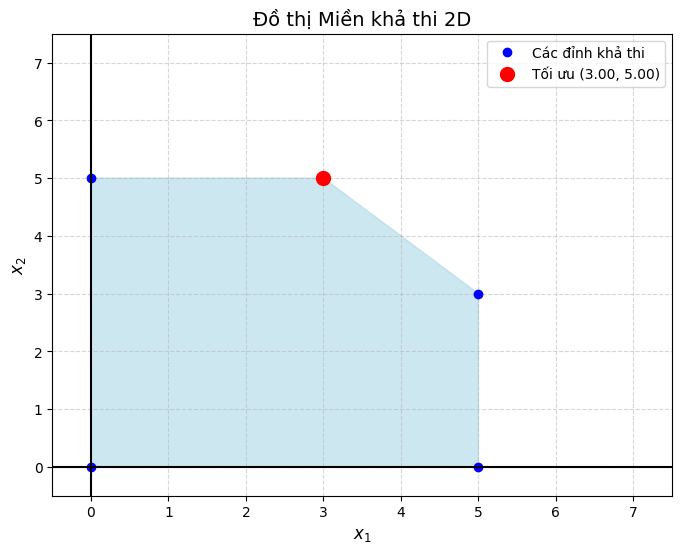

In [ ]:
# ---------------------------------------------------------
# TEST 8: KIỂM TRA TÍNH NĂNG VẼ ĐỒ THỊ 2D (THÀNH CÔNG)
# Mục đích: Đảm bảo thuật toán vẽ đa giác hoạt động với bài toán 2 biến.
# Sử dụng lại solver_dantzig của Test 7
# ---------------------------------------------------------
print("\n[TEST 8] Kiểm tra tính năng vẽ đồ thị 2D")
fig, msg = solver_dantzig.plot_feasible_region()
if fig is not None:
    print("-> Trạng thái: THÀNH CÔNG (Đã tạo thành công đối tượng Figure).")
    # Bỏ comment dòng dưới để hiển thị biểu đồ pop-up trên máy tính
    # plt.show()
else:
    print(f"-> Trạng thái: THẤT BẠI - Lỗi: {msg}")

In [ ]:
# ---------------------------------------------------------
# TEST 9: KIỂM TRA TÍNH NĂNG VẼ ĐỒ THỊ (TỪ CHỐI BÀI TOÁN 3 BIẾN)
# Mục đích: Hệ thống phải tự động từ chối vẽ hình nếu số biến > 2.
# MAX Z = x1 + x2 + x3
# x1 + x2 + x3 <= 10
# x1, x2, x3 >= 0
# ---------------------------------------------------------
print("\n[TEST 9] Kiểm tra từ chối vẽ đồ thị (Bài toán 3 chiều)")
solver_3d = SimplexDictionarySolver(
    num_vars=3, num_constraints=1, objective_type='MAX',
    c=[1, 1, 1], A=[[1, 1, 1]], b=[10],
    bound_signs=['<='], var_signs=['>=0', '>=0', '>=0']
)
solver_3d.solve()
fig_3d, msg_3d = solver_3d.plot_feasible_region()
if fig_3d is None:
    print(f"-> Trạng thái: THÀNH CÔNG TỪ CHỐI. Lời nhắn: {msg_3d}")
else:
    print("-> Trạng thái: LỖI (Hệ thống đã cố vẽ bài toán 3 biến).")


[TEST 9] Kiểm tra từ chối vẽ đồ thị (Bài toán 3 chiều)
-> Trạng thái: THÀNH CÔNG TỪ CHỐI. Lời nhắn: Lỗi: Chỉ hỗ trợ vẽ đồ thị cho bài toán có đúng 2 biến quyết định.


In [ ]:
# ---------------------------------------------------------
# TEST 10: CƠ CHẾ ANTI-CYCLING (CHỐNG LẶP)
# Mục đích: Dùng bài toán Beale kích hoạt bằng Dantzig.
# Nếu hệ thống bắt đầu đạp vòng, nó phải tự động fallback về Bland.
# ---------------------------------------------------------
print("\n[TEST 10] Kiểm tra cơ chế chống lặp (Anti-Cycling Fallback)")
solver_beale = SimplexDictionarySolver(
    num_vars=4, num_constraints=3, objective_type='MAX',
    c=['3/4', -20, '1/2', -6],
    A=[['1/4', -8, -1, 9],
        ['1/2', -12, '-1/2', 3],
        [0, 0, 1, 0]],
    b=[0, 0, 1],
    bound_signs=['<=', '<=', '<='],
    var_signs=['>=0', '>=0', '>=0', '>=0'],
    pivot_rule="DANTZIG"
)
solver_beale.solve()
print("-> Kỳ vọng: TỐI ƯU (Hệ thống tự động điều tiết để không bị crash).")
print(f"-> Thực tế: Trạng thái: {solver_beale.status} | Z_opt = {solver_beale.Z_opt}")
print(f"-> Quy tắc kết thúc: {solver_beale.pivot_rule}")
print("="*50)


[TEST 10] Kiểm tra cơ chế chống lặp (Anti-Cycling Fallback)
-> Kỳ vọng: TỐI ƯU (Hệ thống tự động điều tiết để không bị crash).
-> Thực tế: Trạng thái: OPTIMAL | Z_opt = 5/4
-> Quy tắc kết thúc: BLAND
